Descriptive Analytics for Numerical Columns

In [3]:
# Importing Packages and Loading Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('C:/Data Science/Assignments_Files/Basic stats - 1/Basic stats - 1/sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [12]:
# Identify numerical columns in the dataset.

numeric_columns=df.select_dtypes(include=['number']).columns
print("Numeric columns in the dataset are:\n",list(numeric_columns))

Numeric columns in the dataset are:
 ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [14]:
# Calculate the mean, median, mode, and standard deviation for these columns.
# Provide a brief interpretation of these statistics.

df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


Data Visualization

In [19]:
# For visualization we have to rename columns !

df=df.rename(columns={'Avg Price':'Avg_Price','Total Sales Value':'Total_Sales_Value',
                      'Discount Rate (%)':'Discount_Rate','Discount Amount':'Discount_Amount',
                      'Net Sales Value':'Net_Value'
                     })
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg_Price,Total_Sales_Value,Discount_Rate,Discount_Amount,Net_Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


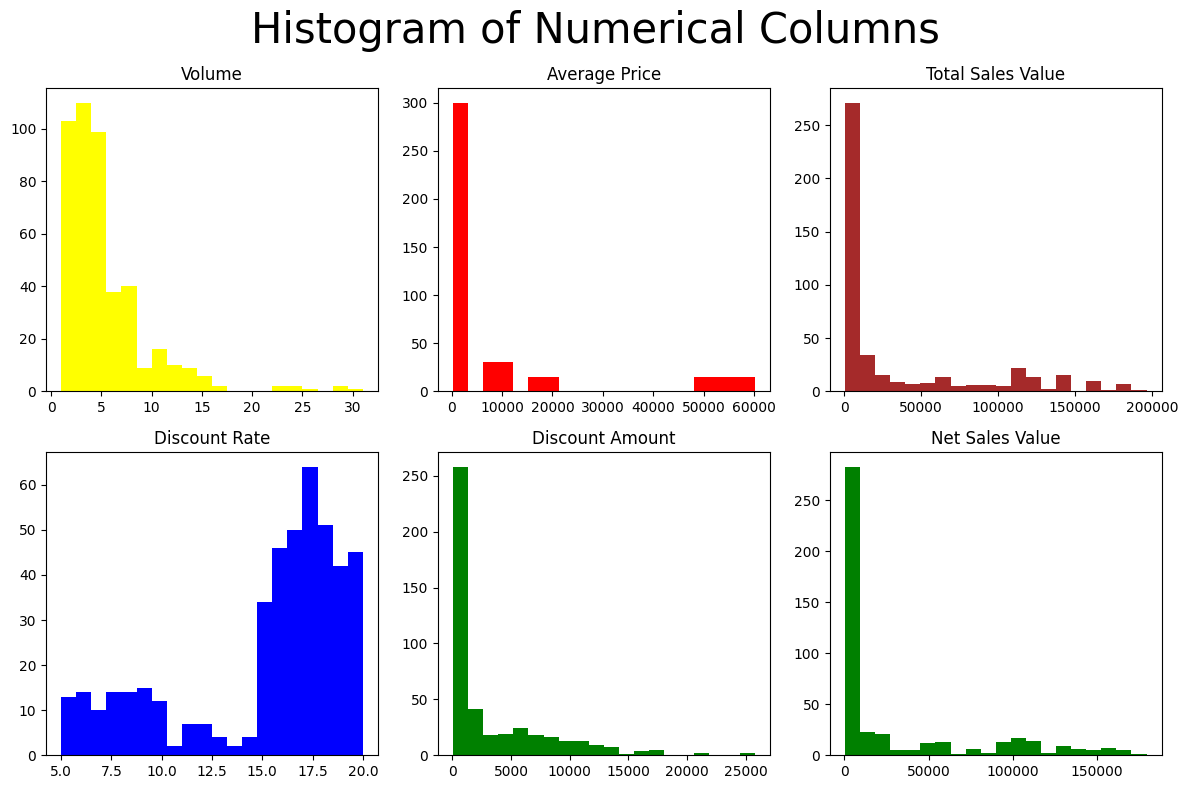

In [21]:
# ●	Histograms:

plt.figure(figsize=(12,8))
plt.subplot(2,3,1)
plt.hist(df.Volume,bins=20,color='yellow')
plt.title("Volume")

plt.subplot(2,3,2)
plt.hist(df.Avg_Price,bins=20,color='red')
plt.title("Average Price")


plt.subplot(2,3,3)
plt.hist(df.Total_Sales_Value,bins=20,color='brown')
plt.title("Total Sales Value")


plt.subplot(2,3,4)
plt.hist(df.Discount_Rate,bins=20,color='blue')
plt.title("Discount Rate")


plt.subplot(2,3,5)
plt.hist(df.Discount_Amount,bins=20,color='green')
plt.title("Discount Amount")

plt.subplot(2,3,6)
plt.hist(df.Net_Value,bins=20,color='green')
plt.title("Net Sales Value")


plt.suptitle("Histogram of Numerical Columns",fontsize=30)
plt.tight_layout()
plt.show()

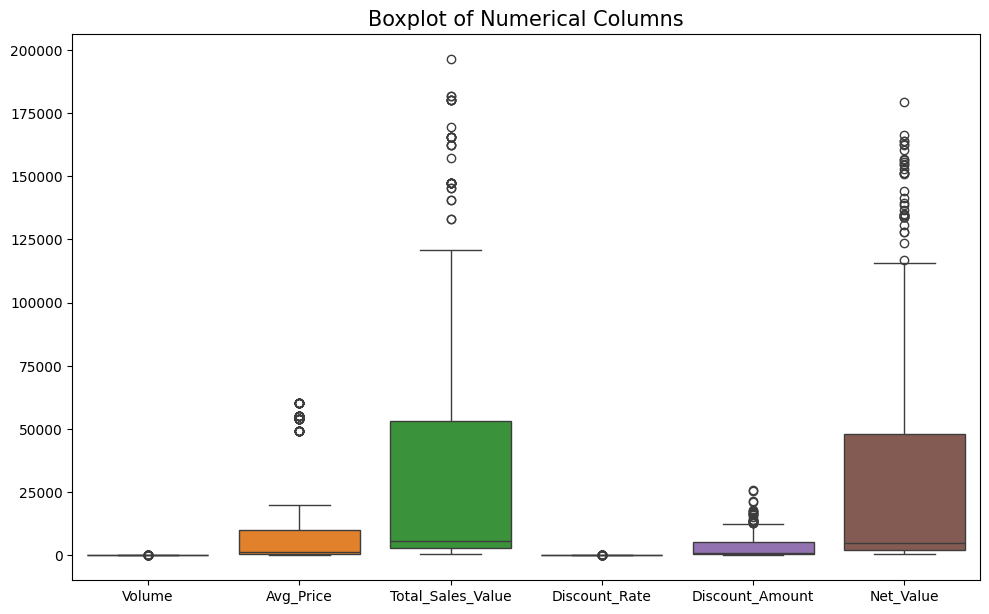

In [23]:
# ●	Boxplots:

plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.tight_layout()
plt.title("Boxplot of Numerical Columns",fontsize=15)
plt.show()

In [29]:
# ●	Bar Chart Analysis for Categorical Column:
# 	Identify categorical columns in the dataset.

cat_col=df.select_dtypes(include=["object"]).columns
print("Categorical Columns in dataset:\n",list(cat_col))

Categorical Columns in dataset:
 ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


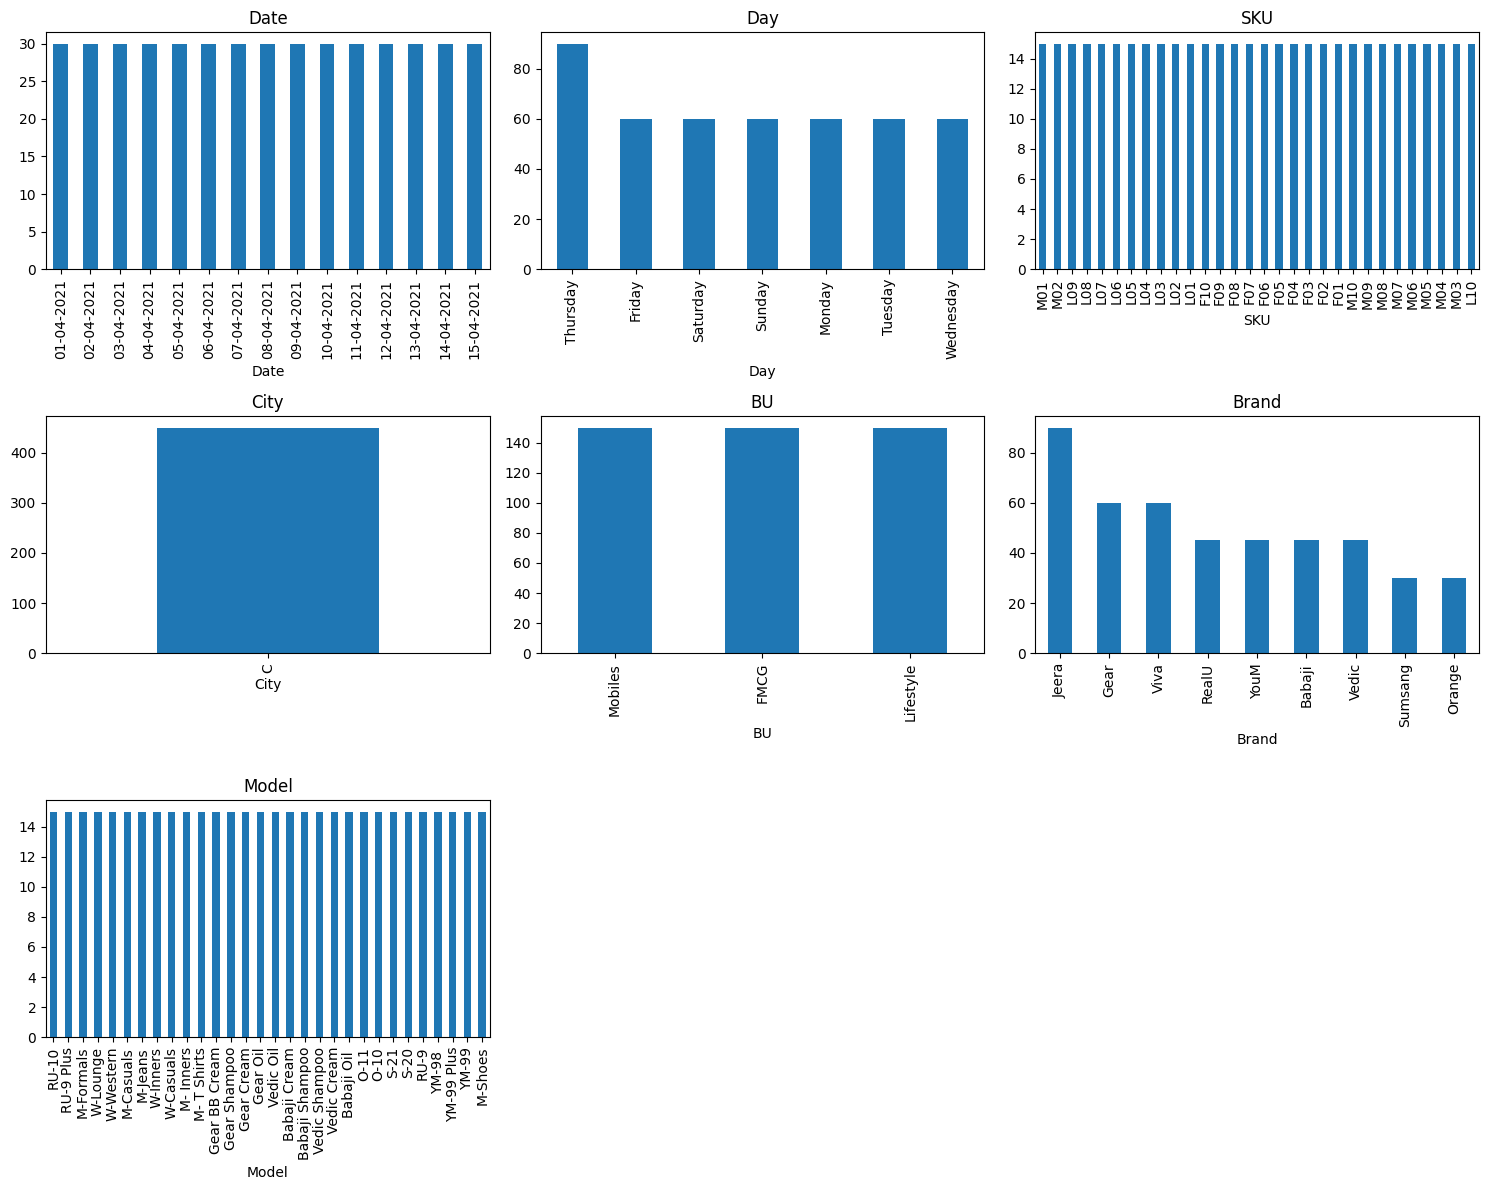

In [31]:
#	Create bar charts to visualize the frequency or count of each category.Analyze the distribution of categories and provide insights

plt.figure(figsize=(15,12))

for i,col in enumerate(cat_col,1):
    plt.subplot(3,3,i)
    df[col].value_counts().plot(kind="bar")
    plt.title(col)

plt.tight_layout()
plt.show()

Standardization of Numerical Variables

In [ ]:
#	Explain the concept of standardization (z-score normalization).

"""
Standardization (also called Z-score normalization) transforms each value using:

z=x-mu/sigma
	
Where:

x = original value

μ (mu) = mean of the column

σ (sigma) = standard deviation of the column

z = standardized value
"""

In [36]:
# 	Standardize the numerical columns using the formula: z=x-mu/sigma. Show before and after comparisons of the data distributions.

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

num_cols = ['Volume', 'Avg_Price', 'Total_Sales_Value',
            'Discount_Rate', 'Discount_Amount', 'Net_Value']

print("Before Standardization")
print(df[num_cols].describe())
print("\n\n")

df_standardized=pd.DataFrame(scaler.fit_transform(df[num_cols]),columns=num_cols)

print("After Standardization")
print(df_standardized.describe())

Before Standardization
           Volume     Avg_Price  Total_Sales_Value  Discount_Rate  \
count  450.000000    450.000000         450.000000     450.000000   
mean     5.066667  10453.433333       33812.835556      15.155242   
std      4.231602  18079.904840       50535.074173       4.220602   
min      1.000000    290.000000         400.000000       5.007822   
25%      3.000000    465.000000        2700.000000      13.965063   
50%      4.000000   1450.000000        5700.000000      16.577766   
75%      6.000000  10100.000000       53200.000000      18.114718   
max     31.000000  60100.000000      196400.000000      19.992407   

       Discount_Amount      Net_Value  
count       450.000000     450.000000  
mean       3346.499424   30466.336131  
std        4509.902963   46358.656624  
min          69.177942     326.974801  
25%         460.459304    2202.208645  
50%         988.933733    4677.788059  
75%        5316.495427   47847.912852  
max       25738.022194  179507.4790



Conversion of Categorical Data into Dummy Variables

In [40]:
df_dummy=pd.get_dummies(df,columns=cat_col,drop_first=False)
df_dummy.head(10)

,Volume,Avg_Price,Total_Sales_Value,Discount_Rate,Discount_Amount,Net_Value,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,3,8100,24300,16.996489,4130.146805,20169.853195,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,3,49100,147300,9.228812,13594.039719,133705.960281,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,2,54100,108200,5.553719,6009.124321,102190.875679,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,2,55100,110200,7.410104,8165.935144,102034.064856,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,3,60100,180300,9.928444,17900.983733,162399.016267,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
